加载SVHN数据集并预处理
从原始数据中分离出图像数据和对应的标签，通过转置操作调整维度顺序
将标签展平后，把所有值为10的标签替换为0，确保标签与0到9的数字分类对应一致

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm import tqdm  


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 64
EPOCHS = 15  # 轻微增加轮数，正则化后不会过拟合
LEARNING_RATE = 0.001
NUM_CLASSES = 10 


train_raw = sio.loadmat("train_32x32.mat")
test_raw = sio.loadmat("test_32x32.mat")

train_X = train_raw["X"]
train_y = train_raw["y"]
test_X = test_raw["X"]
test_y = test_raw["y"]
print(f"原始训练集数据维度: {train_X.shape}, 标签维度: {train_y.shape}")
print(f"原始测试集数据维度: {test_X.shape}, 标签维度: {test_y.shape}")

# 维度转换
train_X = np.transpose(train_X, (3, 2, 0, 1))
test_X = np.transpose(test_X, (3, 2, 0, 1))
print(f"转换后训练集数据维度: {train_X.shape}")

# 标签处理
train_y = train_y.flatten()
test_y = test_y.flatten()
train_y[train_y == 10] = 0
test_y[test_y == 10] = 0

原始训练集数据维度: (32, 32, 3, 73257), 标签维度: (73257, 1)
原始测试集数据维度: (32, 32, 3, 26032), 标签维度: (26032, 1)
转换后训练集数据维度: (73257, 3, 32, 32)


采用随机裁剪、随机水平翻转、随机旋转三种增强方式，同时进行归一化处理，将图像像素值标准化到合适的范围，加速模型收敛
测试集只进行归一化处理

In [2]:
# 训练集：数据增强 + 归一化
train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomCrop(32, padding=4),  # 随机裁剪
    transforms.RandomHorizontalFlip(p=0.5), # 随机水平翻转
    transforms.RandomRotation(10),          # 随机旋转
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 测试集：仅归一化
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

将预处理后的数据集封装成PyTorch的Dataset格式，通过DataLoader实现批次加载。

In [3]:
class SVHNDataset(Dataset):
    def __init__(self, data, labels, transform=None):
        self.data = data
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img = np.transpose(self.data[idx], (1, 2, 0))
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)

# 分别传入不同的transform
train_dataset = SVHNDataset(train_X, train_y, transform=train_transform)
test_dataset = SVHNDataset(test_X, test_y, transform=test_transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)


使用三层卷积块加两层全连接层结构训练

In [4]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        # 卷积块：Conv + BN + ReLU + Pool + Dropout2d
        self.conv1 = nn.Conv2d(3, 16, 3, 1, 1)
        self.bn1 = nn.BatchNorm2d(16)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)
        self.drop1 = nn.Dropout2d(0.2)  # 空间Dropout
        
        self.conv2 = nn.Conv2d(16, 32, 3, 1, 1)
        self.bn2 = nn.BatchNorm2d(32)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)
        self.drop2 = nn.Dropout2d(0.3)
        
        self.conv3 = nn.Conv2d(32, 64, 3, 1, 1)
        self.bn3 = nn.BatchNorm2d(64)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(2, 2)
        self.drop3 = nn.Dropout2d(0.3)
        
        # 全连接层：提高Dropout率
        self.fc1 = nn.Linear(64 * 4 * 4, 128)
        self.relu4 = nn.ReLU()
        self.dropout = nn.Dropout(0.5)  # 0.2 → 0.5 强正则化
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.drop1(self.pool1(self.relu1(self.bn1(self.conv1(x)))))
        x = self.drop2(self.pool2(self.relu2(self.bn2(self.conv2(x)))))
        x = self.drop3(self.pool3(self.relu3(self.bn3(self.conv3(x)))))
        x = x.view(-1, 64 * 4 * 4)
        x = self.relu4(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = SimpleCNN(num_classes=NUM_CLASSES).to(device)

使用交叉熵损失函数、Adam优化器并加入weight_decay参数实现L2正则化、采用ReduceLROnPlateau策略定义学习率调度器。

In [5]:
criterion = nn.CrossEntropyLoss()
# 加入 weight_decay 实现L2正则化
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
# 学习率调度器：验证损失不下降时，自动降低学习率
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5, verbose=True)


/root/miniconda3/envs/py310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


训练模型

In [6]:


train_loss_list = []
train_acc_list = []
test_loss_list = []
test_acc_list = []

for epoch in range(EPOCHS):
    # 训练阶段
    model.train()
    train_running_loss = 0.0
    train_correct = 0
    train_total = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    epoch_train_loss = train_running_loss / len(train_loader)
    epoch_train_acc = 100 * train_correct / train_total
    train_loss_list.append(epoch_train_loss)
    train_acc_list.append(epoch_train_acc)

    # 验证阶段
    model.eval()
    test_running_loss = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            test_running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()

    epoch_test_loss = test_running_loss / len(test_loader)
    epoch_test_acc = 100 * test_correct / test_total
    test_loss_list.append(epoch_test_loss)
    test_acc_list.append(epoch_test_acc)

    # 更新学习率调度器
    scheduler.step(epoch_test_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}% | Test Loss: {epoch_test_loss:.4f} | Test Acc: {epoch_test_acc:.2f}%")

print(f"\n训最终测试准确率: {test_acc_list[-1]:.2f}%")

Epoch 1/15: 100%|█████████████████████████████████| 1145/1145 [01:28<00:00, 12.89it/s]


Epoch 1/15 | Train Loss: 2.1829 | Train Acc: 21.71% | Test Loss: 1.8517 | Test Acc: 33.94%


Epoch 2/15: 100%|█████████████████████████████████| 1145/1145 [01:28<00:00, 12.96it/s]


Epoch 2/15 | Train Loss: 1.9726 | Train Acc: 29.52% | Test Loss: 1.6893 | Test Acc: 38.35%


Epoch 3/15: 100%|█████████████████████████████████| 1145/1145 [01:27<00:00, 13.01it/s]


...

Epoch 13/15 | Train Loss: 1.1166 | Train Acc: 63.03% | Test Loss: 0.6391 | Test Acc: 80.05%


Epoch 14/15: 100%|████████████████████████████████| 1145/1145 [01:27<00:00, 13.09it/s]


Epoch 14/15 | Train Loss: 1.0742 | Train Acc: 64.67% | Test Loss: 0.5742 | Test Acc: 82.20%


Epoch 15/15: 100%|████████████████████████████████| 1145/1145 [01:27<00:00, 13.13it/s]


Epoch 15/15 | Train Loss: 1.0476 | Train Acc: 65.86% | Test Loss: 0.5650 | Test Acc: 82.56%

训最终测试准确率: 82.56%


可视化损失曲线和准确率曲线

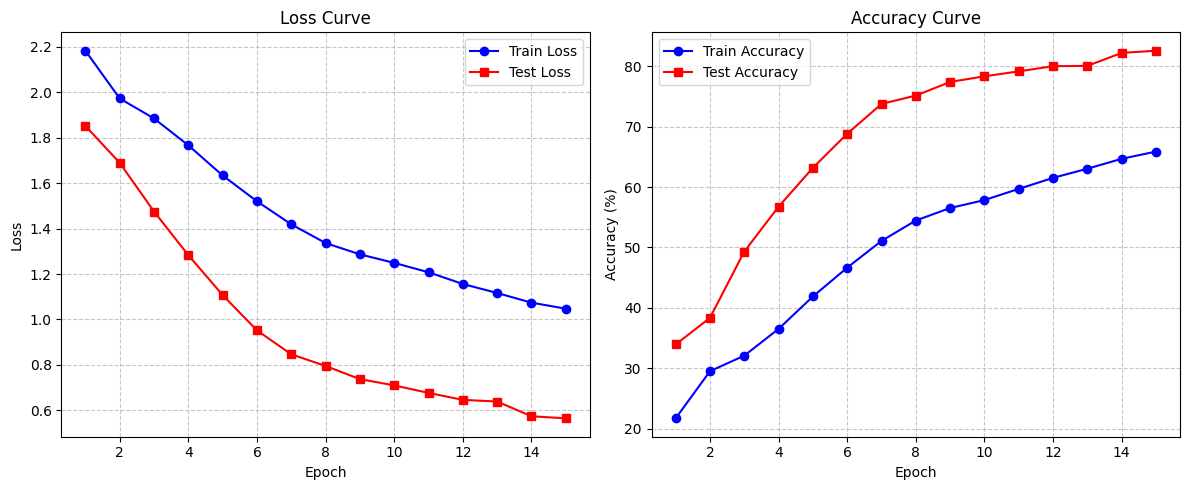

In [7]:
plt.figure(figsize=(12, 5))
# 损失曲线
plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS+1), train_loss_list, label="Train Loss", color="blue", marker="o")
plt.plot(range(1, EPOCHS+1), test_loss_list, label="Test Loss", color="red", marker="s")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid(linestyle="--", alpha=0.7)

# 准确率曲线
plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS+1), train_acc_list, label="Train Accuracy", color="blue", marker="o")
plt.plot(range(1, EPOCHS+1), test_acc_list, label="Test Accuracy", color="red", marker="s")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Curve")
plt.legend()
plt.grid(linestyle="--", alpha=0.7)

plt.tight_layout()
plt.savefig("svhn_cnn_training_result.png", dpi=300)
plt.show()